# Исследование рынка заведений общественного питания Москвы

- Автор: Ульзана Давлетова

### Цели и задачи проекта

**Целью** проекта является анализ рынка заведений общественного питания для открытия новой точки в Москве.<br>
Основные **задачи** исследования:<br>
 - поиск подходящего *расположения* для открытия нового заведения общепита<br>
 - выбор наиболее выгодного *типа заведения*: кафе, ресторан, бар и т.д.<br>
 - определение оптимального количества *посадочных мест*<br>
 - выбор *ценовой категории* будущего заведения

### Описание данных

Для анализа используются данные с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят из двух датасетов:<br><br>
1) `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:<br>
 - `name` — название заведения;
 - `address` — адрес заведения;
 - `district` — административный район, в котором находится заведение;
 - `category` — категория заведения;
 - `hours` — информация о днях и часах работы;
 - `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
 - `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым: (0 — не является сетевым, 1 — является сетевым);
 - `seats` — количество посадочных мест.<br><br>

2) `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
 - `price` — категория цен в заведении;
 - `avg_bill` — средняя стоимость заказа в виде диапазона;
 - `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино».</font>

### Содержание проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Выводы и рекомендации


## 1. Загрузка данных и знакомство с ними


In [2]:
# Импортируем необходимые библиотеки

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix

In [3]:
# Выгружаем данные
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся со структурой данных и выведем первые 5 строк каждого датасета

In [4]:
def data_info(data):
    print('Информация о датасете:')
    print (data.info())
    print ('________________________________________________')
    print ('Первые 5 строк датасета:')
    display (data.head())
    print ('________________________________________________')
    print ('Количество пропусков в абсолютном выражении:')
    print (data.isna().sum().sort_values())
    print ('________________________________________________')
    print ('Количество пропусков в относительном выражении:')
    print (data.isna().mean().sort_values().round(3))
    print ('________________________________________________')
    duplicates = data.duplicated().sum()
    print('Количество дубликатов:')
    print (duplicates)     

data_info (rest_info)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB
None
________________________________________________
Первые 5 строк датасета:


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


________________________________________________
Количество пропусков в абсолютном выражении:
id             0
name           0
category       0
address        0
district       0
rating         0
chain          0
hours        536
seats       3611
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
id          0.000
name        0.000
category    0.000
address     0.000
district    0.000
rating      0.000
chain       0.000
hours       0.064
seats       0.430
dtype: float64
________________________________________________
Количество дубликатов:
0


Датасет `rest_info` содержит 9 столбцов и 8406 строк. <br>
*Названия столбцов*: соответствуют описанию и имеют вид в соответствии со стандартом snake_case.<br>
*Пропуски*: содержатся в столбцах `hours` и `seats`. <br>
*Типы данных*: данные в столбцах `id`, `name`, `category`, `address`, `district`, `hours` имеют тип object, что удобно для анализа. Столбец `rating` имеет тип данных float64. Можно оптимизировать данный тип, так как он имеет небольшие числовые значения. Также можно и поступить со столбцом `chain`, имеющим тип данных int64 - столбец имеет значения либо 0, либо 1, размерность этих данных тоже можно оптимизировать. Столбец `seats` имеет тип данных float64, что не совсем подходит для данных: число мест не может быть дробным, поэтому лучше преобразовать данные в тип int.<br><br>
Приступим к следующему датасету.

In [5]:
data_info(rest_price)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB
None
________________________________________________
Первые 5 строк датасета:


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


________________________________________________
Количество пропусков в абсолютном выражении:
id                      0
avg_bill              242
price                 743
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
id                   0.000
avg_bill             0.060
price                0.183
middle_avg_bill      0.224
middle_coffee_cup    0.868
dtype: float64
________________________________________________
Количество дубликатов:
0


Датасет `rest_price` содержит 5 столбцов и 4058 строк.<br>
*Названия столбцов*: соответствуют описанию и имеют вид в соответствии со стандартом snake_case.<br>
*Пропуски*: содержатся во всех столбцах, кроме `id`, максимум пропусков приходится на столбец `middle_coffee_cup` - 87%. Возможно, не во всех заведениях готовят капучино.<br>
*Типы данных*: данные в столбцах имеют оптимальный тип, изменений не требуется.

In [6]:
def data_info(data):
    print('Информация о датасете:')
    print (data.info())
    print ('________________________________________________')
    print ('Первые 5 строк датасета:')
    display (data.head())
    print ('________________________________________________')
    print ('Количество пропусков в абсолютном выражении:')
    print (data.isna().sum().sort_values())
    print ('________________________________________________')
    print ('Количество пропусков в относительном выражении:')
    print (data.isna().mean().sort_values().round(3))
    print ('________________________________________________')
    duplicates = data.duplicated().sum()
    print('Количество дубликатов:')
    print (duplicates) 


---

### Промежуточный вывод

В целом, данные не требуют больших изменений. Достаточно корректировки типов данных в некоторых столбцах. Первый датасет не имеет большого количетва пропусков, что не скажешь о втором, где максимум пропусков приходится на столбец `middle_coffee_cup` - 87%. Нужен более детальный анализ пропущенных значений

### Подготовка единого датафрейма
При объединении двух датасетов получаем таблицу с 13 столбцами и 8406 строками. Обе таблицы объединяем полностью без потери данных.

In [7]:
df = rest_info.merge (rest_price, on='id', how='outer')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

1. Изучаем корректность типов данных, преобразуем их.

In [8]:
df['rating'] = pd.to_numeric(df['rating'],downcast='float')
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float32(1), float64(3), int8(1), object(8)
memory usage: 763.6+ KB


Мы преобразовали типы данных в двух столбцах:
 - `rating` - оптимизировали тип до float32
 - `chain` - оптимизировали тип до int8<br>

Преобразование типа данных в столбце `seats` пока невозможно, так как необходимо заполнить пропущенные значения.

2. Изучаем пропущенные значения в данных: выведем их количество в каждом столбце датафрейме

In [9]:
print ('Количество пропусков в абсолютном выражении:')
print (df.isna().sum().sort_values())
print()
print ('Количество пропусков в относительном выражении:')
print (df.isna().mean().sort_values().round(3))

Количество пропусков в абсолютном выражении:
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
hours                 536
seats                3611
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Количество пропусков в относительном выражении:
id                   0.000
name                 0.000
category             0.000
address              0.000
district             0.000
rating               0.000
chain                0.000
hours                0.064
seats                0.430
avg_bill             0.546
price                0.606
middle_avg_bill      0.625
middle_coffee_cup    0.936
dtype: float64


Проанализируем пропуски более детально:<br>
- В лидерах по пропускам  столбец `middle_coffee_cup` (94%). Возможно, из-за того, что не все категории заведений имеют в меню капучино либо категория заведения не специализируется на напитках с кофе. Степень его заполненности зависит от наличия определенных значений в столбце `avg_bill`.
- 43% пропусков имеет столбец `seats`. Может быть, некоторые заведения имеют обслуживание только "на вынос". Но доля пропусков все-таки велика. Возможно, в карточке заведения на Картах этот пункт был не заполнен.
- Столбец `middle_avg_bill` имеет 62% пропусков. Как и в случае со столбцом `middle_coffee_cup` степень его заполненности зависит от наличия определенных значений в столбце `avg_bill`.
- Столбец `price` имеет пропущенные значения в рамере  61%. Можно попробовать их заполнить в соответствии с расположением заведения и его категорией. Тут 3 варанта гипотезы возникновения пропусков: либо владельцы в карточке заведения на Картах не заполнили данную информацию, либо этот показатель заполняется на усмотрение посетителя, когда он оставляет отзыв. Может быть, система сама автоматически присваеивает категорию цен, но при отсутствии самих цен на блюда, категория не была выставлена.
- Столбец `avg_bill` имеет 55 % пропусков. Возможно, заведения не указали прейскурант в своих карточках на Картах.
- Наменьшее количество пропусков в столбце `hours`  - около 6%. Предположительно, что также заведения не указали время работы.

Попробуем найти взаимосвязь категории цен и категории заведения в разбивке по районам. Возможно, удастся таким образом заполнить пропуски

In [10]:
for_prices = df.pivot_table( index=['category','price'], columns='district', values='middle_avg_bill', aggfunc='min')
for_prices.round().style.format('{:,}')

К сожалению, идея не увенчалась успехом: мы видим противоречивые показатели. Например, в "столовой" в Северном административном округе низкая ценовая категория имеет показатель 240 рублей, а средняя ценовая категория - 225 рублей, чего не должно быть. В других типах заведений видим ту же картину. Если применить фукцию 'mean' или 'median', то резутаты также будут противоречивыми.  Скорее всего, категория цен не определяется диапазоном или средним чеком. Пропуски оставляем незаполненными.

В процессе обработки найдено некорректное название заведения. Исправим его, заглянув на Карту

In [11]:
df[df['name']=='Untitled']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
4938,982bc191e93a4560a337498f1dc760d5,Untitled,кафе,"Москва, Яузский бульвар, 14/8",Центральный административный округ,NaN,4.5,0,16.0,средние,Средний счёт:1500–2000 ₽,1750.0,NaN


In [12]:
df.loc[4938, 'name'] = df.loc[4938, 'name'].replace('Untitled', 'ложечка')
df.loc[4938]

id                     982bc191e93a4560a337498f1dc760d5
name                                            ложечка
category                                           кафе
address                   Москва, Яузский бульвар, 14/8
district             Центральный административный округ
hours                                               NaN
rating                                              4.5
chain                                                 0
seats                                              16.0
price                                           средние
avg_bill                       Средний счёт:1500–2000 ₽
middle_avg_bill                                  1750.0
middle_coffee_cup                                   NaN
Name: 4938, dtype: object

Есть заведения с общими названиями, но их достаточно много. Данные приведены за 2022 год, некоторые заведения уже не работают, поэтому восстановить корректные данные не представляется возможным. Например:

In [13]:
df[df['name']=='Кафе']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
25,00f5f2510bc342f3af364847da60825a,Кафе,кафе,"Москва, Профсоюзная улица, 144",Юго-Западный административный округ,"ежедневно, круглосуточно",4.6,0,0.0,NaN,NaN,NaN,NaN
105,03e4cbbd86de4014a22ccd8249c85a6d,Кафе,кафе,"Москва, Дубнинская улица, 52, стр. 1",Северный административный округ,"ежедневно, 10:00–20:00",3.9,0,70.0,NaN,NaN,NaN,NaN
133,04af0afe56cf452ebfec2847d5993475,Кафе,кофейня,"Москва, улица Авиаконструктора Сухого, 2, корп. 1",Северный административный округ,"пн-пт 09:00–23:00; сб,вс 09:00–22:00",4.5,0,NaN,NaN,NaN,NaN,NaN
202,06e2f6de06ac48f7a12880b0ac0fe4e8,Кафе,кафе,"Москва, Дубнинская улица, 53, корп. 2",Северный административный округ,NaN,4.3,0,124.0,NaN,NaN,NaN,NaN
205,06e52c7e482b45518d91cb1b798f0b6e,Кафе,кафе,"Москва, МКАД, 30-й километр, 6",Южный административный округ,"ежедневно, круглосуточно",4.0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8153,f80fb97b789a4363bb3a36d98f1773af,Кафе,кафе,"Москва, улица Юности, 2, стр. 29",Восточный административный округ,NaN,2.7,0,NaN,NaN,NaN,NaN,NaN
8267,fb9c7ebffbef48918e6f99e887d783f8,Кафе,кафе,"Москва, улица Твардовского, 8, корп. 4",Северо-Западный административный округ,NaN,3.7,0,12.0,NaN,NaN,NaN,NaN
8271,fba8a8321985484a9663f1656a10917e,Кафе,кафе,"Москва, улица Матросская Тишина, 15/17с7",Восточный административный округ,пн-пт 09:00–18:00,4.0,0,NaN,NaN,NaN,NaN,NaN
8306,fcbd7c0186b54ee78f11e2e2d834eb9c,Кафе,кофейня,"Москва, Волоколамское шоссе, 103",Северо-Западный административный округ,"ежедневно, 08:00–20:00",4.1,0,NaN,NaN,NaN,NaN,NaN


3. Проверим данные на явные и неявные дубликаты

Приведем названия заведений к нижнему регистру и найдем неявные дубликаты:

In [14]:
df['name']=df['name'].str.lower()

In [15]:
for column in ['category', 'district', 'rating', 'chain', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце rating:
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]

Уникальные значения в столбце chain:
[0 1]

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



Все значения корректные, неявных дубликатов нет<br><br>
Теперь заполним пропуски в столбце `seats` и приведем к типу данных integer:

In [16]:
df['seats'] = df['seats'].fillna(0)
df['seats'] = pd.to_numeric(df['seats'], downcast='integer')

Явных дубликатов не выявлено:

In [17]:
df.duplicated().sum()

np.int64(0)

---

Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [18]:
def is_24_7 (row):
    if row ['hours']== 'ежедневно, круглосуточно':
        return True
    return False

df['is_24_7'] = df.apply(is_24_7, axis=1)

Создадим столбец `rating_grades`, сгруппировав рейтинги в диапазоны с шагом 0,5:

In [19]:
df['rating_grades']=pd.cut(
    df['rating'], 
    bins=[0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0],
    labels=['0.0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '3.0-3.5', '3.5-4.0', '4.0-4.5', '4.5-5.0'])

Также для работы понадобится столбец `seats_yes_no` с указанием, есть ли посадочные места в заведении, или нет:
 - значение `Yes` — если в заведении есть посадочные места;
  - значение `No` — посадочных мест нет.

In [20]:
def seats_yes_no (row):
    if row ['seats']> 0:
        return 'Yes'
    return 'No'

df['seats_yes_no'] = df.apply(seats_yes_no, axis=1)

---

### Промежуточный вывод

Выведем инфо итогового датафрейма.

In [21]:
data_info(df)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   object  
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float32 
 7   chain              8406 non-null   int8    
 8   seats              8406 non-null   int16   
 9   price              3315 non-null   object  
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_24_7            8406 non-null   bool    
 14  rating_grades      8406 non-null   category
 15  seats_yes_no       8406 non-null

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7,rating_grades,seats_yes_no
0,0009f005d6fb47c6b067db5084f4e05a,кафе лоза,ресторан,"Москва, Череповецкая улица, 4А",Северо-Восточный административный округ,"ежедневно, круглосуточно",4.2,0,85,средние,Средний счёт:500–800 ₽,650.0,NaN,True,4.0-4.5,Yes
1,000c4f8e2c6b4a8e81127ed094688658,добролавка,кофейня,"Москва, Столярный переулок, 3к13",Центральный административный округ,"пн-пт 09:00–21:00; сб,вс 10:00–21:00",4.4,0,0,средние,Цена чашки капучино:150–190 ₽,NaN,170.0,False,4.0-4.5,No
2,0028eb1543284e18a0acdb0343a66107,кафе бульвар. шашлык-сити,кафе,"Москва, 7-я Парковая улица, 15, стр. 3",Восточный административный округ,"ежедневно, 11:00–00:00",4.3,0,0,NaN,NaN,NaN,NaN,False,4.0-4.5,No
3,002a2a1a30b84ad1883408ad5cec661f,булошная,кофейня,"Москва, Новочерёмушкинская улица, 58",Юго-Западный административный округ,"ежедневно, 09:00–22:00",4.4,1,20,NaN,NaN,NaN,NaN,False,4.0-4.5,Yes
4,002c7e0b7c294daf944229bc10597566,j&j cafe moscow,кофейня,"Москва, Верхняя Красносельская улица, 16",Центральный административный округ,пн-пт 09:00–18:00,4.1,0,0,средние,Цена чашки капучино:170–250 ₽,NaN,210.0,False,4.0-4.5,No


________________________________________________
Количество пропусков в абсолютном выражении:
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
seats                   0
is_24_7                 0
rating_grades           0
seats_yes_no            0
hours                 536
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
id                   0.000
name                 0.000
category             0.000
address              0.000
district             0.000
rating               0.000
chain                0.000
seats                0.000
is_24_7              0.000
rating_grades        0.000
seats_yes_no         0.000
hours                0.064
avg_bill             0.546
price                0.606
mi

В результате предобработки данных мы получили датасет, состоящий из 16 столбцов и 8406 строк. Типы данных некоторых столбцов были оптимизированы, в столбце `seats` пропуски замнены на нули. Остальные пропуски не были обработаны в силу невозможности заполнения значений: если заполнять данные средними значениями, то результат может исказиться. Названия заведений приведены к нижнему регистру. Явных и неявных дубликатов не выявлено, удалений строк и столбцов не проводилось. Добавлены 3 столбца `is_24_7` (Круглосуточные и некруглосуточные) и `rating_grades` (группы рейтингов), `seats_yes_no` (наличие посадочных мест), которые будут использоваться в последующем анализе

## 3. Исследовательский анализ данных

---

###  Исследуем количество объектов общественного питания по каждой категории.

Для удобства создадим диаграмму, которая отобразит количество заведений общественного питания по категориям.

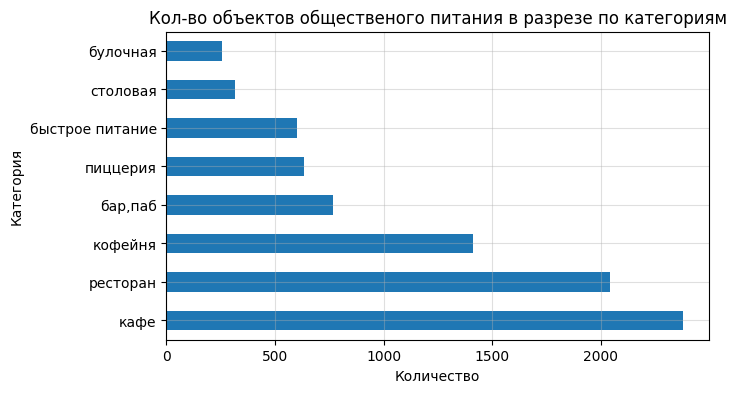

In [22]:
categories = df['category'].value_counts().plot(
        kind='barh', 
        figsize = (7,4),
        title='Кол-во объектов общественого питания в разрезе по категориям'
)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.grid(alpha=0.4)
plt.show()

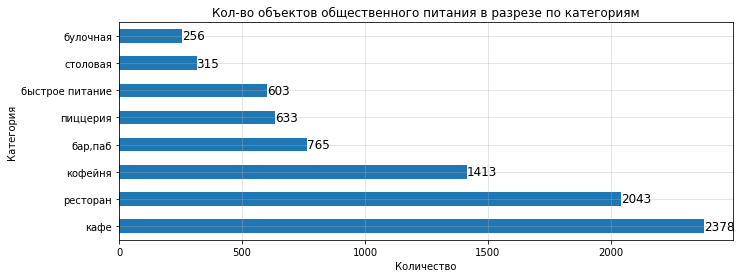

In [22]:

# Сначала получаем данные
category_counts = df['category'].value_counts()

# Создаем график
fig, ax = plt.subplots(figsize=(11, 4))
bars = category_counts.plot(kind='barh', ax=ax)

# Настраиваем подписи
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.title('Кол-во объектов общественного питания в разрезе по категориям')
plt.grid(alpha=0.4)

# Добавляем числовые значения
for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width,  # координата x
        bar.get_y() + bar.get_height()/2,  # координата y
        f'{width}',
        ha='left',  # выравнивание по левому краю
        va='center',  # вертикальное выравнивание по центру
        fontsize=12,
        color='black'
    )

plt.show()

График показывает, что самая распространенная категория объектов - это кафе, количество заведений составляет 2378. Возможно, из-за того, что это ниболее универсальный вариант объекта общепита. В отличии от ресторанов, здесь не такие высокие цены, еда приемлемого качества (не везде, конечно). Также в тройке лидеров ресторан и кофейня. Самый непопулярный объект - булочная (256 объектов). Скорее всего, булочная не так популярна, потому что это устаревший формат, который менее привлекает посетителей. Сейчас более востребованы гибридные заведения, типа пекарен-кофеен, где ассортимент не ограничивается выпечкой. Недалеко от булочной ушла столовая - чуть более 300 объектов. Существует миф о том, что в столовых не соблюдают санитарные нормы. Также зачастую посетители приходят в заведение не только поесть, но и отдохнуть, поэтому для них важна атмосфера: уют, удобство, официанты...

---

### Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. 

Создадим диаграмму, отражающую количество заведений в каждом округе

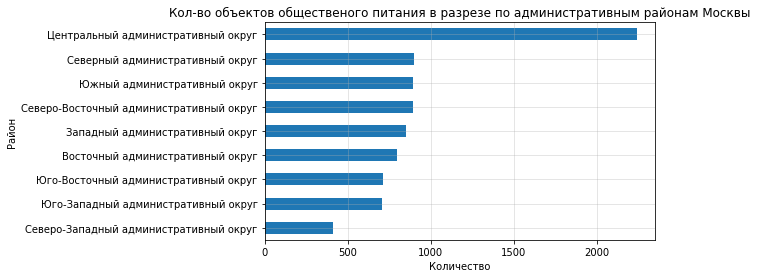

In [23]:
districts = df.groupby('district')['id'].count().sort_values()
districts.plot(
        kind='barh', 
        figsize = (7,4),
        title='Кол-во объектов общественого питания в разрезе по административным районам Москвы'
)
plt.xlabel('Количество')
plt.ylabel('Район')
plt.grid(alpha=0.4)
plt.show()

На графике видно, чем ближе к центру, тем больше объектов. В лидерах Центральный адиминистративный округ, в котором более 2000 заведений. Меньшинство объектов в Северо-Западном административном округе с количеством объектов менее 500. Это неудивительно: в спальных районах заведения общепита менее востребованы, а в центре больше бизнес-объектов, большой поток горожан, а также туристов. Непопулярность объектов в спальных районах может быть вызвана ростом доставки готовой еды.

Посмотрим более детально на объекты общепита в Центральном административном округе.

In [24]:
filered_district = df[(df['district']=='Центральный административный округ')&(df['category'])]

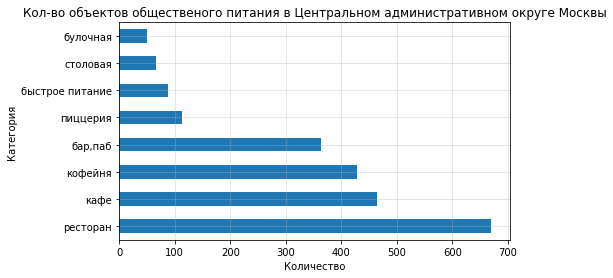

In [25]:
center = filered_district['category'].value_counts().plot(
        kind='barh', 
        figsize = (7,4),
        title='Кол-во объектов общественого питания в Центральном административном округе Москвы'
)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.grid(alpha=0.4)
plt.show()

Здесь лидирующие позиции занимает ресторан, затем кафе и кофейня. Рестораны пользуются большей популярностью ввиду того, что в центре сосредоточено больше офисных объектов, и зачастую рабочие моменты обсуждают в заведениях общественного питания. Контингент более высокого материального уровня, который может позволить посещать дорогие заведения. А оригинальная концепция и близость к достопримечательностям привлекает больший поток посетителей. <br>
К сожалению, булочной или столовой сейчас сложнее удивить искушенного посетителя, поэтому он наименее привлекателен.

---

### Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. 

Создадим график для отображения сетевых и несетевых заведений.

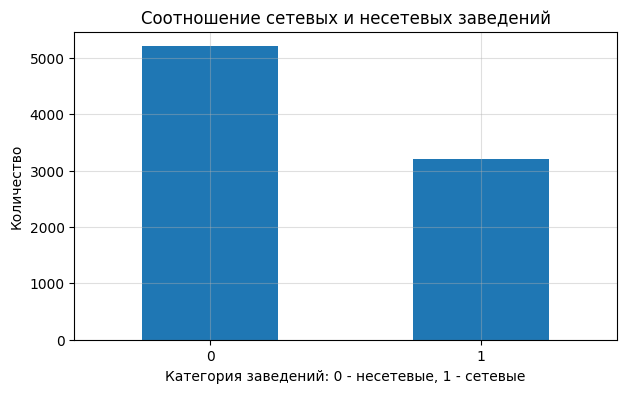

In [39]:
chains = df['chain'].value_counts().plot(
        kind='bar', 
        figsize = (7,4),
        rot=0,
        title='Cоотношение сетевых и несетевых заведений'  
)
plt.ylabel('Количество')
plt.xlabel('Категория заведений: 0 - несетевые, 1 - сетевые')
plt.grid(alpha=0.4)
plt.show()

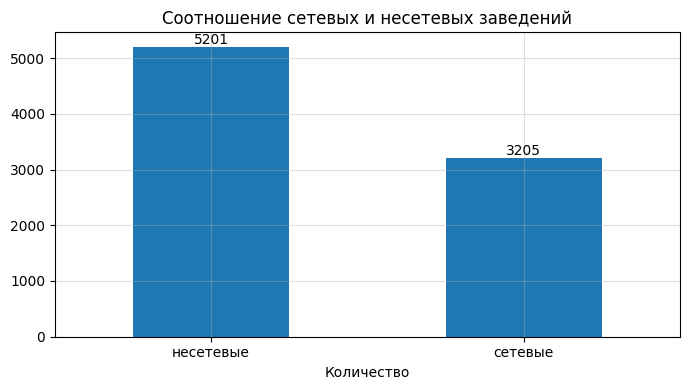

In [40]:

# Сначала получаем данные и строим график
chain_counts = df['chain'].value_counts()

# Создаем график
fig, ax = plt.subplots(figsize=(7, 4))
bars = chain_counts.plot(kind='bar', ax=ax)

# Новые метки
new_labels = ['несетевые', 'сетевые']

# Устанавливаем новые метки
plt.xticks(ticks=chain_counts.index, labels=new_labels)  # Важно использовать chain_counts.index

# Остальные настройки
plt.xlabel('Количество')
plt.title('Соотношение сетевых и несетевых заведений')
plt.xticks(rotation=0)
plt.grid(alpha=0.4)

# Дополнительно можно добавить значения на столбцы
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,  # смещение сверху
        f'{height}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()  # Для правильного размещения всех элементов
plt.show()


Количество несетевых объектов значительно выше, чем сетевых: 5201 против 3205. Вероятно, несетевые заведения имеют больше возможностей для создания своего собственного формата, разработки уникальной концепции, в то время как сетевые заведения имеют рамки, ограничения, уже установленные правила внутри сети, которые обеспечивают узнаваемость бренда. Сетевые объекты менее гибкие в изменении концепции и формата, так как требует больших финансовых и временнЫх затрат.

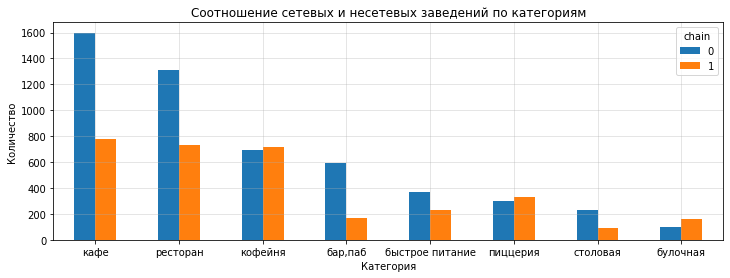

In [28]:
sorted_grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0).sort_values(by=0, ascending=False)
sorted_grouped.plot(kind='bar',
               title='Соотношение сетевых и несетевых заведений по категориям',
               legend=True,
               rot=0,
               figsize=(12, 4))
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.grid(alpha=0.4)
plt.show()

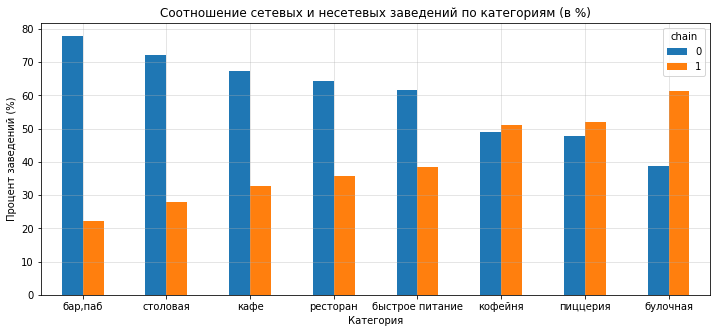

In [29]:
sorted_grouped_percent = sorted_grouped.div(sorted_grouped.sum(axis=1), axis=0) * 100
sorted_grouped_percent = sorted_grouped_percent.sort_values(by=0, ascending=False)
sorted_grouped_percent.plot(
    kind='bar',
    title='Соотношение сетевых и несетевых заведений по категориям (в %)',
    legend=True,
    rot=0,
    figsize=(12, 5)
)
plt.ylabel('Процент заведений (%)')
plt.xlabel('Категория')
plt.grid(alpha=0.4)
plt.show()

На графике видно, что в подавляющем большинстве типов объектов предобадают несетевые заведения. Из всех категорий сетевых больше в булочной, кофейне, пиццерии. Несетевых объектов в два раза больше в кафе, ресторане, столовой. Максимально большой разброс в категории бар - несетевых объектов больше сетевых в три раза. Склоняюсь, что, действительно, иметь несетевой объект менее рисковано, так как можно быстро подстроиться к новшествам и идти в ногу с тем, что в спросе у посетителей.

---

### Исследуем количество посадочных мест в заведениях. 


Выведем статистические показатели для данных по количеству посадочных мест.

In [30]:
df['seats'].describe()

count    8406.000000
mean       61.846538
std       107.175995
min         0.000000
25%         0.000000
50%        20.000000
75%        85.000000
max      1288.000000
Name: seats, dtype: float64

Ранее пропуски в данном столбце были заменены на нули. Пропуски могли возникнуть либо из-за нехватки информации, либо из-за того, что в заведении нет посадочных мест. Количество пропусков составляет 43%. Эти пропуски очень сильно влияют на статистические показатели: медиана и средняя имеет большой разрыв, стандартное отклонение тоже имеет большой показатель. Есть аномально высокие значения и выбросы.<br><br>
Отбросим все нули.

In [31]:
new_df = df.loc[df['seats']>0]
new_df['seats'].describe().reset_index().round()

,index,seats
0,count,4659.0
1,mean,112.0
2,std,123.0
3,min,1.0
4,25%,40.0
5,50%,79.0
6,75%,143.0
7,max,1288.0


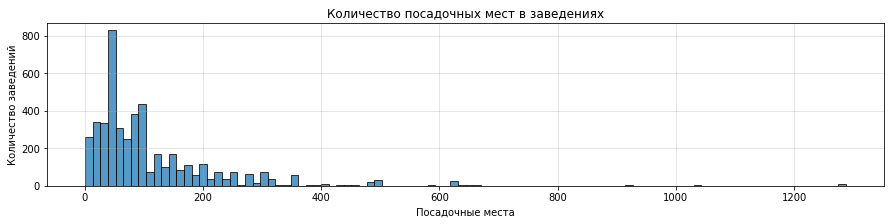

In [32]:
new_df['seats'].plot(
            kind='hist',
            bins=100, 
            alpha=0.75,
            edgecolor='black',
            rot=0,
            title='Количество посадочных мест в заведениях',
            figsize=(15, 3)
)
plt.xlabel('Посадочные места')
plt.ylabel('Количество заведений')
plt.grid(alpha=0.4)
plt.show()

На графике видны аномальные значения - количество посадочных мест более 800, 1000, 1200. Возможна, произошла ошибка при вводе данных. Построим ящик

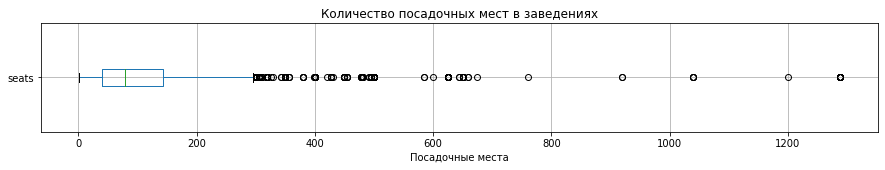

In [33]:
plt.figure(figsize=(15, 2))
new_df.boxplot(column='seats', vert=False)
plt.title('Количество посадочных мест в заведениях')
plt.xlabel('Посадочные места')
plt.show()

Здесь более явно видны аномальные выбросы с большим разрывом. Посмотрим на показатели в разрезе по категориям

In [34]:
new_df.groupby('category')['seats'].describe().reset_index().round()

,category,count,mean,std,min,25%,50%,75%,max
0,"бар,паб",464.0,126.0,145.0,6.0,48.0,84.0,150.0,1288.0
1,булочная,137.0,97.0,98.0,3.0,35.0,52.0,130.0,625.0
2,быстрое питание,331.0,104.0,107.0,1.0,36.0,75.0,150.0,1040.0
3,кафе,1174.0,101.0,119.0,1.0,40.0,60.0,120.0,1288.0
4,кофейня,727.0,115.0,128.0,2.0,40.0,80.0,150.0,1288.0
5,пиццерия,417.0,97.0,113.0,1.0,30.0,56.0,120.0,1288.0
6,ресторан,1250.0,124.0,124.0,2.0,49.0,90.0,155.0,1288.0
7,столовая,159.0,103.0,124.0,4.0,40.0,80.0,120.0,1200.0


Видим аномальные странности в максимальных величинах, а также в минимальных: вряд ли будут открывать ресторан на 2 посадочных места. Посмотрим на показатели в разрезе районов. Возможно, есть какие-то зависимости. Для этого создадим сводную таблицу и выведем только максимальные значения

In [35]:
share = new_df['seats'].quantile(0.99)
df_enormous_seats = new_df.loc[new_df['seats']>=share]
pd.pivot_table(df_enormous_seats, index='district', values='seats', aggfunc=['count', 'min', 'max'],margins=True)

,count,min,max
,seats,seats,seats
district,,,
Восточный административный округ,7,660,1040
Западный административный округ,20,650,1288
Северный административный округ,23,625,625
Юго-Западный административный округ,2,644,644
Южный административный округ,1,675,675
All,53,625,1288


Аномально высокие значения в Западном и Восточном административных округах. Вероятно, там была допущена ошибка при вводе данных. Избавимся от самых минимальных и максимальных значений.

In [36]:
share1 = new_df['seats'].quantile(0.985)
share2 = new_df['seats'].quantile(0.04)
new_df_99 = new_df.loc[new_df['seats']<=share1]
new_df_clean = new_df_99.loc[new_df_99['seats']>share2]
new_df_group = new_df_clean.groupby('category')['seats'].describe().round()
new_df_group = new_df_group.reset_index()
new_df_group

,category,count,mean,std,min,25%,50%,75%,max
0,"бар,паб",450.0,111.0,93.0,12.0,48.0,82.0,140.0,480.0
1,булочная,124.0,101.0,87.0,12.0,38.0,76.0,138.0,478.0
2,быстрое питание,286.0,116.0,92.0,12.0,46.0,86.0,160.0,500.0
3,кафе,1091.0,98.0,89.0,12.0,40.0,70.0,120.0,500.0
4,кофейня,667.0,111.0,90.0,12.0,45.0,86.0,150.0,500.0
5,пиццерия,397.0,93.0,85.0,12.0,35.0,60.0,120.0,455.0
6,ресторан,1212.0,119.0,96.0,12.0,50.0,90.0,152.0,500.0
7,столовая,151.0,96.0,76.0,15.0,40.0,80.0,120.0,428.0


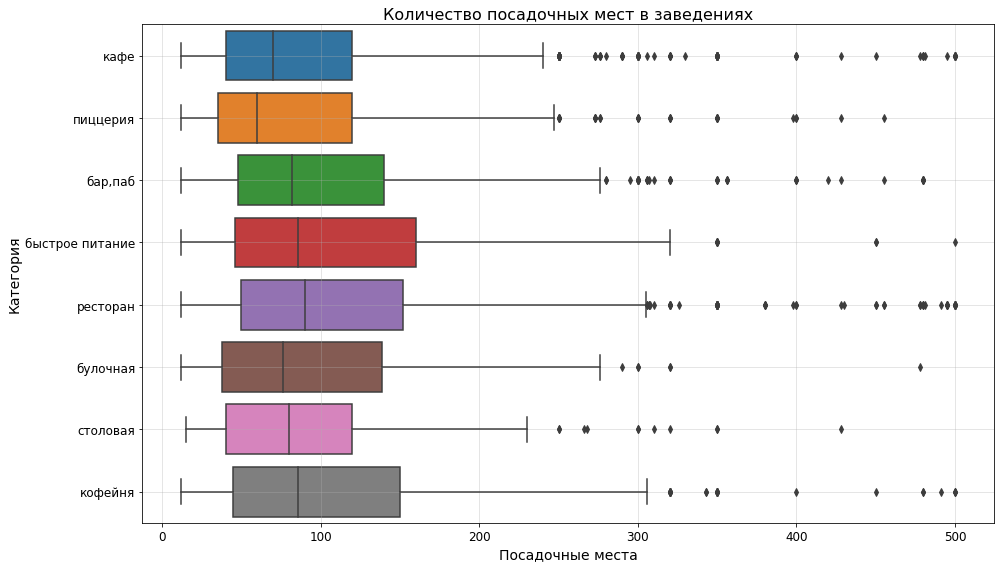

In [37]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='seats', 
    y='category', 
    data=new_df_clean,
)

plt.title('Количество посадочных мест в заведениях', fontsize=16)
plt.xlabel('Посадочные места', fontsize=14)
plt.ylabel('Категория',fontsize=14)
plt.grid(alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Теперь данные выглядят более корректными. Но мы видим, что среднее значение по некоторым категориям значительно отличается от медианы. Стандартное отклонение имеет большой показатель. Разброс великоват, нет равновесия. Подозрение, что изначально данные были не совсем точными (например, сомнения в правдивости данных для булочной и быстрого питания).<br><br>
Выведем моду

In [38]:
pd.pivot_table(new_df_clean, values='seats', index='category', aggfunc={'seats': lambda x: x.mode().iloc[0]})

,seats
category,
"бар,паб",60
булочная,48
быстрое питание,40
кафе,40
кофейня,100
пиццерия,40
ресторан,100
столовая,40


Данные вычисления больше похожи на истинные, стандартные. Желательно придерживаться этих значений.

Рассмотрим категории объектов, которые не имеют посадочных мест

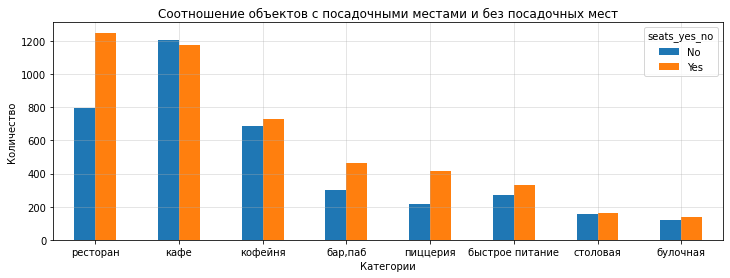

In [39]:
seatss=df.groupby('category')['seats_yes_no'].value_counts().unstack(fill_value=0).sort_values(by='Yes', ascending=False)
seatss.plot(kind='bar',
               title='Соотношение объектов с посадочными местами и без посадочных мест',
               legend=True,
               rot=0,
               figsize=(12, 4))
plt.ylabel('Количество')
plt.xlabel('Категории')
plt.grid(alpha=0.4)
plt.show()

Такой формат заведений (без посадочных мест) тоже пользуется популярностью, особенно в категории Кафе. К сожалению, неизвестно, означает ли пропуск отсутствие посадочных мест или же отсутствие данных. Вообще, можно организовать to-go формат, имея посадочные места, то есть скомбинировать оба варианта.

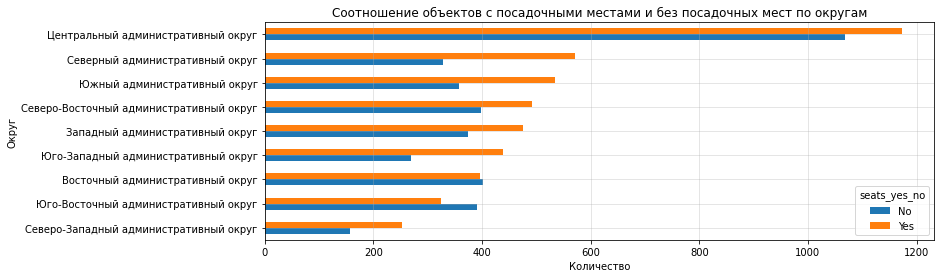

In [40]:
seatss=df.groupby('district')['seats_yes_no'].value_counts().unstack(fill_value=0).sort_values(by='Yes')
seatss.plot(kind='barh',
               title='Соотношение объектов с посадочными местами и без посадочных мест по округам',
               legend=True,
               rot=0,
               figsize=(12, 4))
plt.ylabel('Округ')
plt.xlabel('Количество')
plt.grid(alpha=0.4)
plt.show()

Только в двух округах объекты to-go формата превышают количество объектов с посадочными местами для посетителей - в Восточном и Юго-Восточном. В остальных округах преобладет привычный формат посещения. Формат доставки и "на вынос" был особенно актуален во время пандемии и набрал обороты. Было бы интересно посмотреть динамику по годам, растет ли доля to-go формата сейчас.<br><br>
Так как мир очень изменчив, то нельзя оставлять без внимания различные способы "общения" с потребителем. Желательно внедрить в проект оба формата.

---

### Исследуем рейтинг заведений. 

Рассчитаем средний рейтинг для каждой категории общепита.

In [41]:
rating = pd.pivot_table(df, values='rating', index='category', aggfunc=['mean', 'count'])
rating.columns = ['mean_rating', 'count']
rating = rating.reset_index().sort_values(by='mean_rating')
rating['mean_rating'] = rating['mean_rating'].round(1)
rating

,category,mean_rating,count
2,быстрое питание,4.1,603
3,кафе,4.1,2378
7,столовая,4.2,315
1,булочная,4.3,256
4,кофейня,4.3,1413
6,ресторан,4.3,2043
5,пиццерия,4.3,633
0,"бар,паб",4.4,765


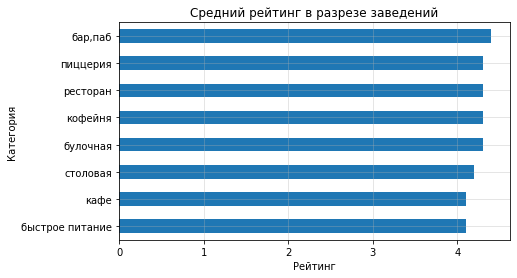

In [42]:
rating.plot(
        kind='barh', 
        figsize = (7,4),
        x='category',
        y='mean_rating',
        title='Средний рейтинг в разрезе заведений',
        legend=False
)
plt.xlabel('Рейтинг')
plt.ylabel('Категория')
plt.grid(alpha=0.4)
plt.show()

График показывает, что заведения имеют хорошие средние рейтинги выше 4 баллов. Для того, чтобы выдержать конкуренцию, необходимо следить за качеством обслуживания и качеством блюд, а также разработать интересную концепцию заведения для привлечения посетителей.

Рассчитаем матрицу корреляции рейтинга с другими данными и построим тепловую карту.

In [43]:
correlation_columns = ['rating','category', 'district', 'chain', 'seats', 'price', 'is_24_7']
correlation_matrix = df [correlation_columns].phik_matrix()
data = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False).round(3)
correlation_matrix

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.198949,0.189389,0.119071,0.000000,0.262056,0.160804
category,0.198949,1.000000,0.174326,0.265627,0.059661,0.566933,0.244789
district,0.189389,0.174326,1.000000,0.064233,0.274944,0.202787,0.076392
chain,0.119071,0.265627,0.064233,1.000000,0.057745,0.218211,0.043414
seats,0.000000,0.059661,0.274944,0.057745,1.000000,0.089453,0.032312
price,0.262056,0.566933,0.202787,0.218211,0.089453,1.000000,0.084183
is_24_7,0.160804,0.244789,0.076392,0.043414,0.032312,0.084183,1.000000


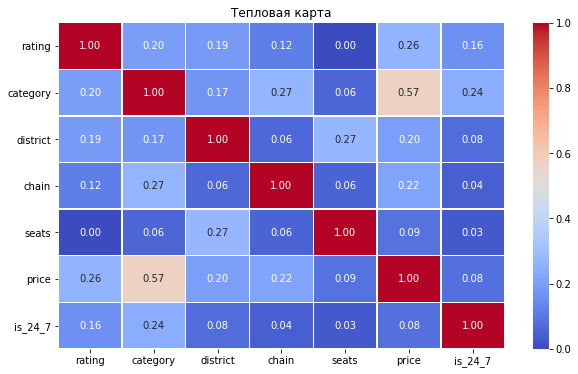

In [44]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Тепловая карта')
plt.yticks(rotation=0)
plt.show()

Мы видим, что самая сильная связь между ценой и категорией объекта - 0,57. Цена имеет самую сильную связь сразу по трем признакам: это и рейтинг, и расположение, и категория. Поэтому необходимо разработать грамотную ценовую политику, чтобы привлечь посетителей и удержать их, обратить внимание на расположение будущего заведения и категорию объекта.<br><br>
Вернемся к рейтингу.

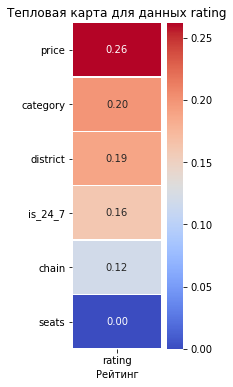

In [45]:
plt.figure(figsize=(2, 6))
sns.heatmap(data,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Тепловая карта для данных rating')
plt.xlabel('Рейтинг')
plt.yticks(rotation=0)
plt.show()

Показатель рейтинга имеет слабые связи с другими значениями, связи нет с показателем количества мест в заведении - на рейтинг не влияет размер заведения. Самая сильная связь - это цена с уровнем 0,26. То есть рейтинг будет выше тогда и только тогда, когда цена будет выше. Проверим гипотезу.

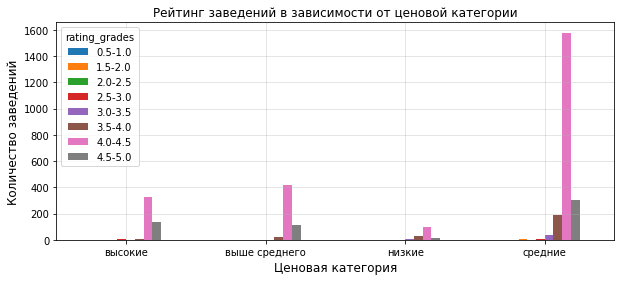

In [46]:
df_rating_price = df.groupby('price')['rating_grades'].value_counts().unstack(fill_value=0)
df_rating_price.plot(
    kind='bar',
    title='Рейтинг заведений в зависимости от ценовой категории',
    legend=True,
    rot=0,
    figsize=(10, 4))
plt.ylabel('Количество заведений', fontsize=12)
plt.xlabel('Ценовая категория', fontsize=12)
plt.grid(alpha=0.4)
plt.show()

В количественном соотношении заведения со средним чеком имеют наибольшее количество положительных оценок. Затем уже идут заведения с чеком выше среднего и высоким. Проанализируем процентное соотношение.

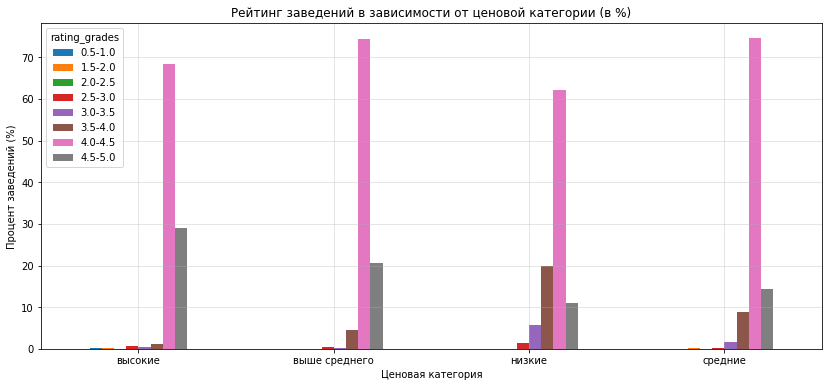

In [47]:
df_rating_price_percent = df_rating_price.div(df_rating_price.sum(axis=1), axis=0) * 100

df_rating_price_percent.plot(
    kind='bar',
    title='Рейтинг заведений в зависимости от ценовой категории (в %)',
    legend=True,
    rot=0,
    figsize=(14, 6)
)
plt.ylabel('Процент заведений (%)')
plt.xlabel('Ценовая категория')
plt.grid(alpha=0.4)
plt.show()


Здесь мы видим, что заведения с высокой ценовой категорией имеют больше высоких оценок, связь прослеживается. Но утверждение, что посетитель высоко оценит заведение из-за высокого чека, странно. Скорее, если обслуживание будет на хорошем уровне, то посетитель поставит высокий балл. От этого можно отталкиваться и пересматривать цены. То есть посетитель готов платить большие деньги за удобное расположение и комфортную атмосферу. В процессе создания нового объекта стоит обратить внимание на уровень обслуживания и потребноти посетителей.

---

### Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве, найдем их средний рейтинг. 

Выведем топ-15 популярных сетей.

In [48]:
df_chains = df[df['chain']==1]
chains_groups = df_chains.groupby(['name', 'category']).agg({'id': 'count', 'rating':'mean'})
chains_groups = chains_groups.sort_values(by='id',ascending=False).reset_index().head(15)
chains_groups=chains_groups.rename(columns = {'id': 'count'})
chains_groups.index = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
chains_groups['rating']=chains_groups['rating'].round(1)
chains_groups

,name,category,count,rating
1,шоколадница,кофейня,119,4.2
2,домино'с пицца,пиццерия,76,4.2
3,додо пицца,пиццерия,74,4.3
4,one price coffee,кофейня,71,4.1
5,яндекс лавка,ресторан,69,3.9
6,cofix,кофейня,65,4.1
7,prime,ресторан,49,4.1
8,кофепорт,кофейня,42,4.1
9,кулинарная лавка братьев караваевых,кафе,39,4.4
10,теремок,ресторан,36,4.1


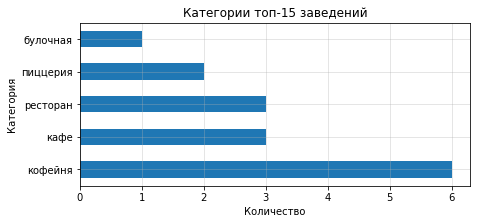

In [49]:
chains_groups['category'].value_counts().plot(
        kind='barh', 
        figsize = (7,3),
        y='rating',
        title='Категории топ-15 заведений'
)
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.grid(alpha=0.4)
plt.show()

Самое большое количество сетевых объектов - это кофейни. Далее ресторан, кафе и пиццерия. 1 сеть - булочная. Не вошли в рейтинг бары, быстрое питание и столовая. Видно, что ниша кофеен уже занята, и будет сложно конкурировать в этом направлении. Пиццерия и булочная узконаправленные категории. Поэтому лучше остановиться на вариантах кафе или ресторан для открытия нового объекта, если нужен проект сети.<br><br>
Посмотрим их средние рейтинги. 

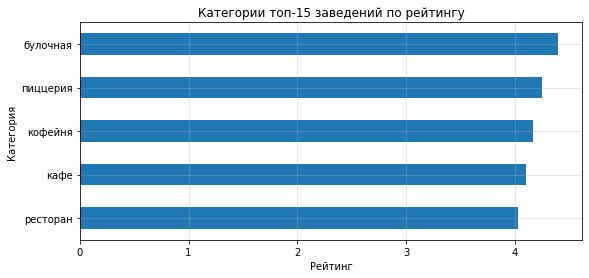

In [58]:
chains_groups_rating = chains_groups.groupby('category')['rating'].mean().sort_values()

chains_groups_rating.plot(
        kind='barh', 
        figsize = (9,4),
        title='Категории топ-15 заведений по рейтингу'
)
plt.xlabel('Рейтинг')
plt.ylabel('Категория')
plt.grid(alpha=0.4)
plt.show()

По рейтингу лидером является булочная, а ресторан и кафе имеют наименьший балл. То есть посетители менее удовлетворены данными заведениями. Есть стимул к развитию именно в этих направлениях. В целом, рейтинги заведений выше 4.

---

### Изучим вариацию среднего чека заведения в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. 

Выведем основные статистические показатели по среднему чеку

In [51]:
df_middle_avg_bill = df[~df['middle_avg_bill'].isna()]
df_bill_describe = df_middle_avg_bill['middle_avg_bill'].describe().reset_index()
df_bill_describe['middle_avg_bill'] = df_bill_describe['middle_avg_bill'].round()
df_bill_describe_styled = df_bill_describe.style.format({'middle_avg_bill':'{:,}'})
df_bill_describe_styled 

,index,middle_avg_bill
0,count,"3,149.0"
1,mean,958.0
2,std,"1,010.0"
3,min,0.0
4,25%,375.0
5,50%,750.0
6,75%,"1,250.0"
7,max,"35,000.0"


По данным можно сделать следующие выводы: 
- минимальный средний чек равен нулю. Возможно, были какие-то акции в заведении (приведешь толпу - бесплатно поешь), либо данные недостоверные.
- максимальный средний чек слишком высок. Скорее всего здесь имеют место выбросы
- средняя  и медиана близки, а стандартное отклонение очень большое, что говорит о наличии выбросов и неоднородности данных.<br><br>
Исключим нулевые показатели и посмотрим разбивку по районам

In [52]:
df_middle_avg_bill = df_middle_avg_bill.loc[df['middle_avg_bill']>0]
df_bill_dist = pd.pivot_table(
               df_middle_avg_bill,
               index=['district'], 
               values='middle_avg_bill', 
               aggfunc=['count', 'mean', 'std', 'min', 'median', 'max'], 
               margins=True)
df_bill_dist[['mean', 'std']] = df_bill_dist[['mean', 'std']].round()
df_bill_dist.reset_index()
df_bill_dist_styled = df_bill_dist.style.format('{:,}')
df_bill_dist_styled

,count,mean,std,min,median,max
,middle_avg_bill,middle_avg_bill,middle_avg_bill,middle_avg_bill,middle_avg_bill,middle_avg_bill
district,,,,,,
Восточный административный округ,260,821.0,851.0,50.0,575.0,"10,000.0"
Западный административный округ,306,"1,053.0",779.0,50.0,"1,000.0","5,250.0"
Северный административный округ,322,928.0,913.0,130.0,650.0,"11,000.0"
Северо-Восточный административный округ,301,717.0,591.0,50.0,500.0,"4,500.0"
Северо-Западный административный округ,157,822.0,595.0,120.0,700.0,"2,900.0"
Центральный административный округ,"1,059","1,192.0",920.0,67.0,"1,000.0","7,250.0"
Юго-Восточный административный округ,194,654.0,567.0,30.0,450.0,"3,750.0"
Юго-Западный административный округ,235,793.0,559.0,100.0,600.0,"2,750.0"


Максимальный покаатель в Южном административном округе, также в Северном и Восточном. Рассмотрим схему

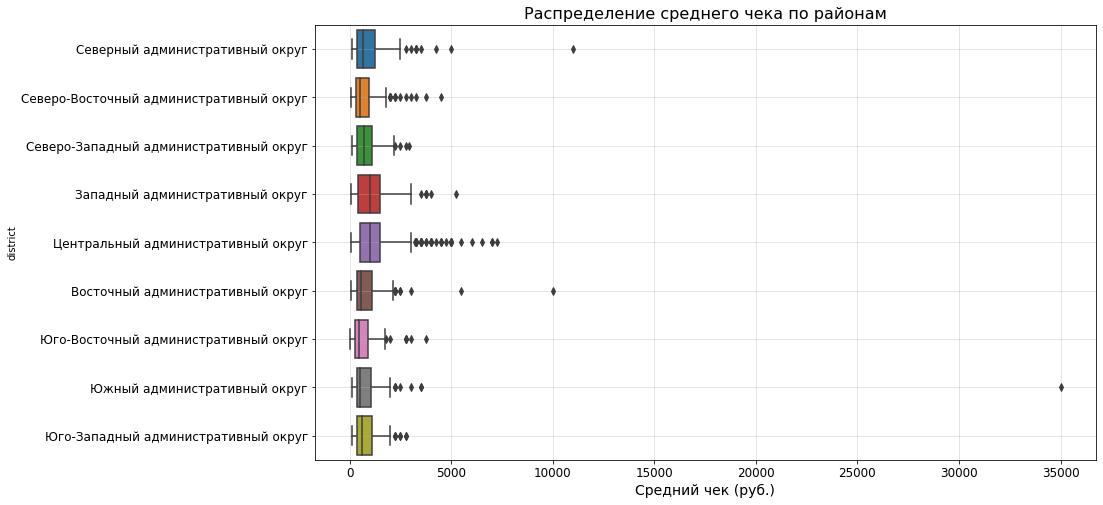

In [53]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='middle_avg_bill', 
    y='district', 
    data=df_middle_avg_bill,
)

plt.title('Распределение среднего чека по районам', fontsize=16)
plt.xlabel('Средний чек (руб.)', fontsize=14)
plt.grid(alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Уберем все сумасшедшие выбросы и посмотрим снова результат

In [54]:
pers_99 = df_middle_avg_bill['middle_avg_bill'].quantile(0.999)
df_middle_avg_bill_99 = df_middle_avg_bill.loc[df_middle_avg_bill['middle_avg_bill']<pers_99]

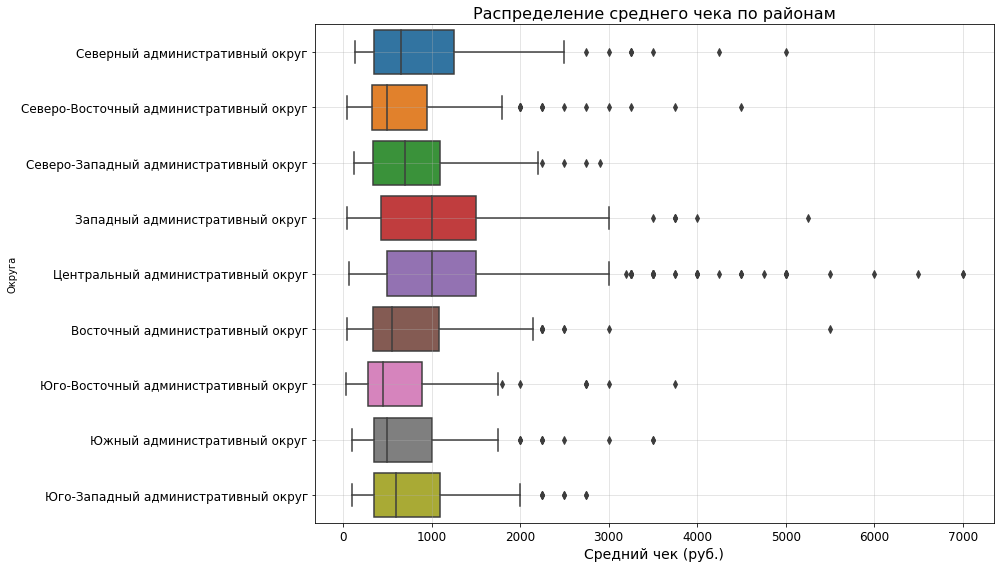

In [59]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='middle_avg_bill', 
    y='district', 
    data=df_middle_avg_bill_99,
)

plt.title('Распределение среднего чека по районам', fontsize=16)
plt.xlabel('Средний чек (руб.)', fontsize=14)
plt.ylabel('Округа')

plt.grid(alpha=0.4)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Теперь данные имеют меньше погрешностей. Западный и Центральный округи почти одинаковы, имеют одинаковую среднюю и медиану. Но в Центральном районе больше чеков с высоким значением.

Добавим еще данные по площади округов

In [56]:
squares = [
['Центральный административный округ', 66.18],
['Северный административный округ', 113.73],
['Северо-Восточный административный округ', 101.88],
['Восточный административный округ', 154.84],
['Юго-Восточный административный округ', 117.56],
['Южный административный округ', 131.77],
['Юго-Западный административный округ', 111.36],
['Западный административный округ', 153.03],
['Северо-Западный административный округ', 93.28]
]

columns = ['district', 'square km']
square = pd.DataFrame (squares, columns = columns)
square.sort_values(by='district')

,district,square km
3,Восточный административный округ,154.84
7,Западный административный округ,153.03
1,Северный административный округ,113.73
2,Северо-Восточный административный округ,101.88
8,Северо-Западный административный округ,93.28
0,Центральный административный округ,66.18
4,Юго-Восточный административный округ,117.56
6,Юго-Западный административный округ,111.36
5,Южный административный округ,131.77


In [57]:
districts_middle_avg_bill = df_middle_avg_bill_99.groupby('district')['middle_avg_bill'].mean().reset_index().sort_values(by='district')
dist = df.groupby('district')['id'].count().reset_index().sort_values(by='district')
fdgdgd = districts_middle_avg_bill.merge( dist,on='district')
districts_full = fdgdgd.merge(square, on='district')
districts_full['middle_avg_bill'] = districts_full['middle_avg_bill'].round()
districts_full = districts_full.rename(columns = {'id':'count'})
districts_full = districts_full.sort_values(by='square km')
districts_full

,district,middle_avg_bill,count,square km
5,Центральный административный округ,1186.0,2242,66.18
4,Северо-Западный административный округ,822.0,409,93.28
3,Северо-Восточный административный округ,717.0,891,101.88
7,Юго-Западный административный округ,793.0,709,111.36
2,Северный административный округ,897.0,900,113.73
6,Юго-Восточный административный округ,654.0,714,117.56
8,Южный административный округ,725.0,892,131.77
1,Западный административный округ,1053.0,851,153.03
0,Восточный административный округ,785.0,798,154.84


Для большей наглядности создадим таблицу со средним чеком, количеством объектов и площадью в разрезе по округам. Данные отсортированы по возрастанию площадей.<br>
Самый маленький по площади округ - Центральный - имеет максимальное количество объектов и самую высокий средний чек. Скорее всего, здесь будет очень сложно конкурировать с другими заведениями ввиду большой плотности объектов общепита. В глаза бросается Западный округ, который имеет тоже довольно высокий средний чек относительно остальных, но площадь округа заметно больше, а количество объектов - меньше. Также Северный округ выглядит привлекательно: количество конкурентов в два раза меньше, площадь больше, средний чек несильно ниже. Можно рассматривать эти два округа и разместиться ближе к Садовому кольцу.

---

### Промежуточный вывод


Исследовательский анализ данных показал следующие результаты:

 - максимальное количество объектов питания приходится на кафе и рестораны - более двух тысяч в каждой категории;
 - большинство объектов общепита сосредоточено в Центральном административном округе, где самая распространенная категория - это ресторан;
 - несетевые заведения пользуются большей популярностью: 5200 объектов, тогда как сетевых объектов - 3200;
 - данные о посадочных местах имеют большой разброс и аномально высокие занчения. Чуть меньше половины заведений не имеет посадочных мест - либо заведения осуществляют только доставку, либо отсутствуют данные. Высокие значения присутствуют в данных по Западному и Восточному округам, что похоже на ошибку в данных. Но модальные значения более похожи на истинные;
 - средний рейтинг заведений варьирует от 4.1 до 4.4;
 - данные имеют слабую связь и зависимость. Максимальное значение имеет пара ценовая категория-категория заведения - 0,57. Пара рейтинг и ценовая категория имеют невысокий коэффициент 0,26. Т.е. чем выше рейтинг, тем выше цены и наоборот;
 - в топ-15 сетевых заведениях по количеству объектов лидируют кофейни, затем рестораны и кафе. Их рейтинги не ниже 4 баллов;
 - в данных по среднему чеку как и в данных по посадочным местам присутствуют аномальные значения до 35 000. Для более объективной оценки такие значения не учитывались. В результате самый высокий средний чек оказался в Центральном и Западном административных округах - более 1000 руб. Самый низкий средний чек - в Северо-Западном округе, составляет 409 рублей.

## 4. Итоговый вывод и рекомендации


В ходе исследования проанализировали 8406 объектов общественного питания в 9 округах Москвы. Данные включали общую информацию о заведениях и ценах. Проведен анализ данных, с помощью которых составлен портрет заведения, привлекающего посетителей. Среди них:  расположение объекта, категория объекта, количество посадочных мест, ценовая категория, рейтинг. Данные имеют недостаток: разброс в значениях. Возможно, потому что информацию на Картах может заполнять любой желающий. 

 
*В результате анализа можно сформулировать следующие выводы:*
 - самыми популярными категориями объектов являются кафе и ресторан. Данные категории универсальны, концепцию заведений можно менять, так как категория однозначно не отражает направление, в отличии от пиццерии, кофейни или булочной.
 - максимальное количество объектов общепита расположено в Центральном административном округе, который одновременно является самым маленьким по площади. При таком раскладе сложно будет конкурировать в центре. В периферии тоже есть свои проблемы: низкий поток посетителей, рост доставки готовой еды. Но здесь можно подстроиться к потребностям клиентов - включить в проект как непосредственное посещение заведения, так и обслуживание "на вынос" и доставка. Привлекательными являются Западный административный округ, который имеет примерно такой же средний чек, и Северный административный округ - у них заметно больше площадь и количество конкурентов в два раза меньше.
 - сетевые заведения заметно уступают несетевым по количеству (3200 и 5200 объектов соответственно). Как вариант можно купить готовую франшизу и не разрабатывать свою собственную концепцию - проще и быстрее. Но сетевым заведениям сложнее подстраиваться к изменениям на рынке и спросу посетителей. В то время как несетевые заведения более гибки в подобных вопросах, им легче адаптироваться к переменам, не требуется больших финансовых и временных затрат.
 - в результате анализа выявлено чуть меньше половины заведений, которые не имеют посадочных мест. Такие показатели говорят о том, что to-go формат популярен среди посетителей. Данный формат присутствует во всех категориях заведений, поэтому следует включить его в проект. Также данный формат будет успешен в спальных районах города и может сократить расходы на аренду помещения. Так как данные по количеству посадочных мест имеют большой разброс, лучше ориентироваться на модальные значения в пределах 40-100 посадочных мест.
 - все заведения общепита имеют хороший средний рейтинг выше 4 баллов на Я.Картах. Наименьший рейтинг имеют категории кафе и быстрое питание. То есть в этих категориях можно предоставить более лучший срвис. Следует позаботиться о репутации заведения в соцсетях, так как хорошая оценка на картах и отзовиках положительно влияет на поток посетителей. При оценке отзывов можно делать выводы об успешной ценовой политике и уровне обслуживания. Исследования показывают, что заведения с высокой и очень высокой ценовой категорией имеют хороший рейтинг. То есть посетителю важно качество обслуживания, уют и атмосфера. За положительные эмоции покупатель готов платить деньги.


*Рекомендации:*
 - желательно открывать заведение несетевого формата `категории` кафе или ресторан с возможностью доставки готовой еды.
 - `расположение`: не стоит размещаться в центре города, так как конкуренция в Центральном округе высокая. Цены за аренду помещений также могут быть выше, чем в других округах.
 - стоит сразу обратить внимание на качество обслуживание и гостеприимность. `Не нужно выбирать низкую ценовую категорию`. За хороший сервис посетитель готов платить более высокую цену. При достижении высокого рейтинга и положительной репутации можно перейти в более дорогой ценовой сегмент.
 - оптимальным количеством `посадочных мест` считается 40-100. Такие значения наиболее типичны для рынка общепита.
 - дополнительно следует проанализировать `стоимость арендной платы` и более детально рассмотреть вопрос размещения объекта.